['datetime', 'price', 'hour']
¿Hay duplicados en el índice? False
Índices duplicados: DatetimeIndex([], dtype='datetime64[us]', name='datetime', freq=None)
Estadístico ADF: -6.4381
p-valor: 0.0000
La serie es estacionaria (p-valor <= 0.05)
Tamaño entrenamiento: 43512 horas (1813 días)
Tamaño prueba:        336 horas  (14 días)
Porcentaje test:      0.8%
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                43512
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -166598.492
Date:                Mon, 06 Apr 2026   AIC                         333204.984
Time:                        16:30:07   BIC                         333239.707
Sample:                    01-01-2020   HQIC                        333215.932
                         - 12-17-2024                                         
Covariance Type:                  opg                                         
            

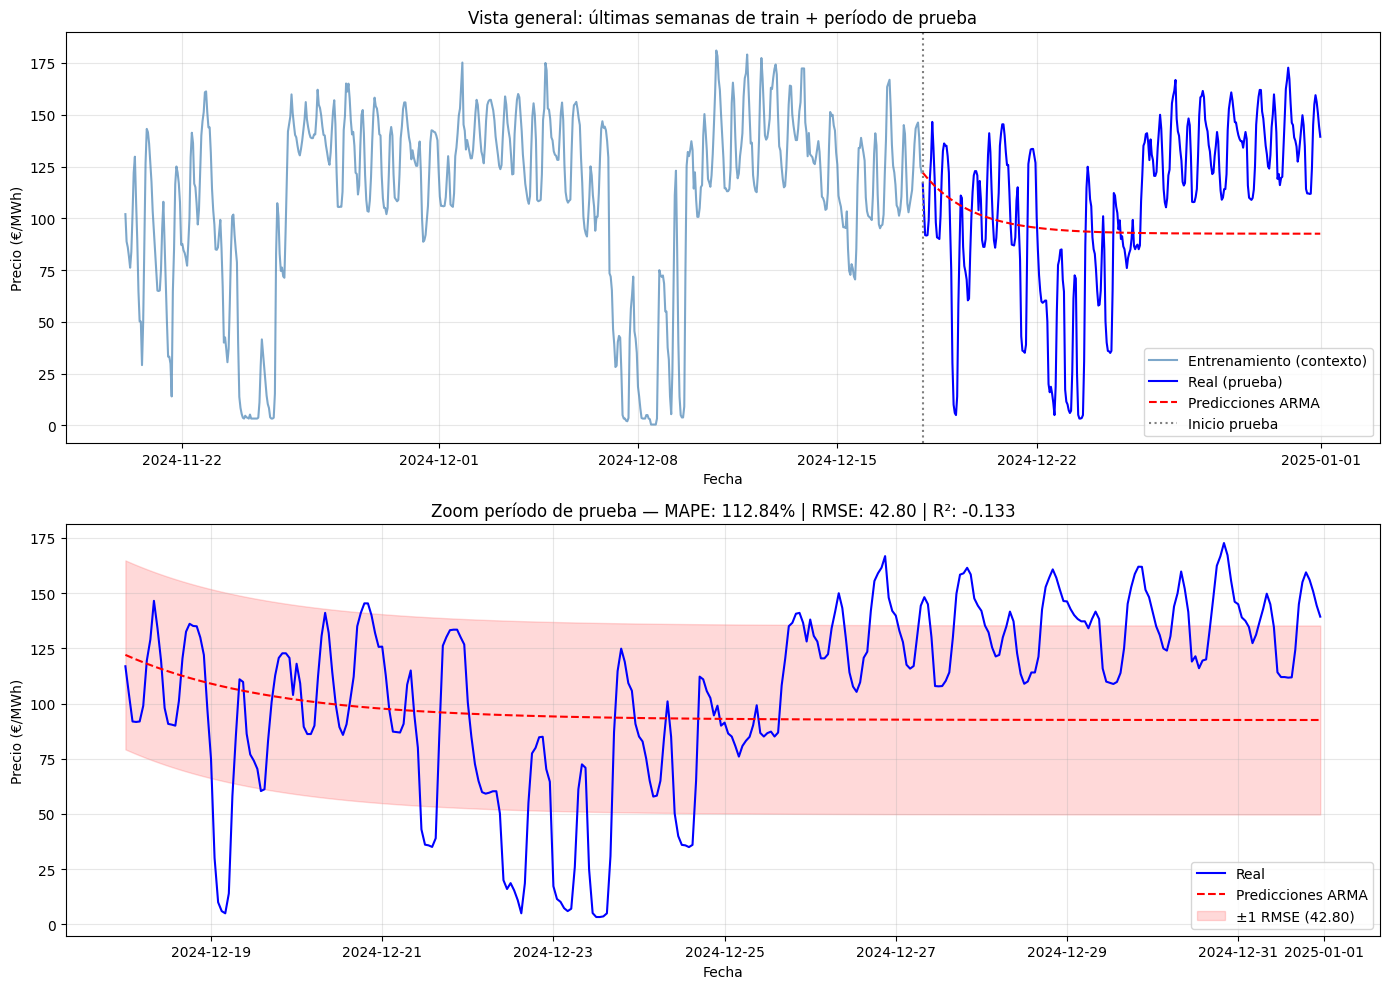

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# ------------------------------
# 1. Cargar los datos
# ------------------------------
df = pd.read_csv('limpiezaPrecio5_Omie2020_2024.csv', sep=";")

# Ver las primeras filas
print(df.columns.tolist())
# ------------------------------
# 2. Preparar la serie temporal
# ------------------------------
# Convertir la columna de datetime a tipo datetime y ponerla como indice
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)


# Seleccionamos la columna de precio (la que queremos predecir)
#serie = df['price']   # precio podria contener valores nulos, por si acaso
serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna() #quitamos valores erroneos

# Comprobar si hay fechas u horas repetidas
print("¿Hay duplicados en el índice?", serie.index.duplicated().any())

duplicados = serie.index[serie.index.duplicated(keep=False)].unique()
print("Índices duplicados:", duplicados[:10])  # muestra los primeros 10 repetdos


# Asigna frecuencia, para nosostros h para una frecuencia en horas
serie = serie.asfreq('h')   # o 'd' para dias

# ==============================
# 3. Verificar estacionariedad (opcional pero recomendado)
# ==============================
# El modelo ARMA asume que la serie es estacionaria.
# Realizamos el test de Dickey-Fuller aumentado.
resultado = adfuller(serie)
print(f'Estadístico ADF: {resultado[0]:.4f}')
print(f'p-valor: {resultado[1]:.4f}')
if resultado[1] <= 0.05:
    print("La serie es estacionaria (p-valor <= 0.05)")
else:
    print("La serie NO es estacionaria. Se recomienda diferenciarla")
    # Diferenciamos una vez
    serie_diff = serie.diff().dropna()
    print("Se ha creado 'serie_diff' para continuar")
    # Vamos a trabajar con la serie diferenciada
    serie = serie_diff

# ==============================
# 4. CORREGIDO División en entrenamiento y prueba
# ==============================
# ultimas 2 semanas del dataset (336 horas) para test, mas representativo
TEST_HOURS = 336  # 2 semanas

train = serie[:-TEST_HOURS]
test  = serie[-TEST_HOURS:]

print(f"Tamaño entrenamiento: {len(train)} horas ({len(train)/24:.0f} días)")
print(f"Tamaño prueba:        {len(test)} horas  ({len(test)/24:.0f} días)")
print(f"Porcentaje test:      {100*len(test)/len(serie):.1f}%")

# ==============================
# 5. Elegir los órdenes p y q del modelo ARMA
# ==============================
# Para simplificar, probamos con p=1, q=1.
# Más adelante puedes probar otros valores (ej. (2,0,1), etc.)
p = 1
q = 1
# En ARIMA, el orden es (p, d, q). Como usamos ARMA, d=0.
modelo = ARIMA(train, order=(p, 0, q))

# Ajustar el modelo
modelo_ajustado = modelo.fit()

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())

# ==============================
# 6. Predecir los valores del conjunto de prueba
# ==============================
# forecast recibe el número de pasos a predecir
predicciones = modelo_ajustado.forecast(steps=len(test))
predicciones.index = test.index   # para que luego se pueda gaficar bien

# ==============================
# 7. AMPLIADA - Métricas de precisión
# ==============================
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae  = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = mean_absolute_percentage_error(test, predicciones) * 100

# Métrica adicional: R² (qué % de varianza explica el modelo)
ss_res = np.sum((test - predicciones) ** 2)
ss_tot = np.sum((test - test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Naive benchmark: predecir siempre el valor anterior (lag-1)
naive_pred = test.shift(1).dropna()
rmse_naive = np.sqrt(mean_squared_error(test[1:], naive_pred))

print("\n========== MÉTRICAS DE PRECISIÓN ==========")
print(f"  MAE   (Error Absoluto Medio):        {mae:.4f} €/MWh")
print(f"  RMSE  (Raíz Error Cuadrático Medio): {rmse:.4f} €/MWh")
print(f"  MAPE  (Error Porcentual Medio):       {mape:.2f}%")
print(f"  R²    (Coeficiente determinación):    {r2:.4f}")
print(f"  RMSE modelo naive (benchmark):        {rmse_naive:.4f} €/MWh")
print(f"  → El modelo es {'MEJOR' if rmse < rmse_naive else 'PEOR'} que el naive")
print("============================================\n")

# ==============================
# 8. CORREGIDA - Gráficas con zoom y separadas
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfica 1: visión global (últimas 4 semanas de train + todo el test) ---
CONTEXTO = 672  # horas de entrenamiento que se muestran como contexto

ax1 = axes[0]
ax1.plot(train[-CONTEXTO:].index, train[-CONTEXTO:],
         label='Entrenamiento (contexto)', color='steelblue', alpha=0.7)
ax1.plot(test.index, test,
         label='Real (prueba)', color='blue', linewidth=1.5)
ax1.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax1.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.5,
            label='Inicio prueba')
ax1.set_title('Vista general: últimas semanas de train + período de prueba')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (€/MWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: zoom solo en el período de prueba ---
ax2 = axes[1]
ax2.plot(test.index, test,
         label='Real', color='blue', linewidth=1.5)
ax2.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax2.fill_between(test.index,
                 predicciones - rmse,
                 predicciones + rmse,
                 alpha=0.15, color='red', label=f'±1 RMSE ({rmse:.2f})')
ax2.set_title(f'Zoom período de prueba — MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | R²: {r2:.3f}')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Precio (€/MWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arma_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()